# Zadanie 3: Optymalizacja modeli operujących na danych sekwencyjnych

## Anna Moroń

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
import os

In [ ]:
def read_csv_with_padding(file_path, sep=';'):
    rows = []
    with open(file_path, newline='', encoding='utf-8') as handle:
        reader = csv.reader(handle, delimiter=sep)
        header = next(reader)
        raw_rows = list(reader)

    expected_columns = max([len(header)] + [len(row) for row in raw_rows])

    if len(header) < expected_columns:
        header = header + [f'empty_{index}' for index in range(len(header) + 1, expected_columns + 1)]
        print(f"Header padded with {expected_columns - len(header)} empty columns.")

    for row in raw_rows:
        if len(row) == expected_columns - 1:
            row.append('0')
        elif len(row) < expected_columns:
            row.extend(['0'] * (expected_columns - len(row)))
        elif len(row) > expected_columns:
            row = row[:expected_columns]
        rows.append(row)

    return pd.DataFrame(rows, columns=header)


df = pd.DataFrame()

for dir in ['A003_2022', 'A003_2023', 'A003_2024', 'A003_2025']:
    for file in os.listdir(f'{dir}/A003'):
        if file.endswith('.csv'):
            print(file)
        else:
            continue

        df_part = read_csv_with_padding(f'{dir}/A003/{file}', sep=';')
        df = pd.concat([df, df_part], ignore_index=True)
        # print(df.shape[0])


A003_20220101_000000_-_20220201_000000_1min.csv
A003_20221101_000000_-_20221201_000000_1min.csv
A003_20220901_000000_-_20221001_000000_1min.csv
A003_20220701_000000_-_20220801_000000_1min.csv
A003_20221201_000000_-_20230101_000000_1min.csv
A003_20220801_000000_-_20220901_000000_1min.csv
A003_20221001_000000_-_20221101_000000_1min.csv
A003_20220201_000000_-_20220301_000000_1min.csv
A003_20220301_000000_-_20220401_000000_1min.csv
A003_20220501_000000_-_20220601_000000_1min.csv
A003_20220601_000000_-_20220701_000000_1min.csv
A003_20220401_000000_-_20220501_000000_1min.csv
A003_20230601_000000_-_20230701_000000_1min.csv
A003_20230301_000000_-_20230401_000000_1min.csv
A003_20230101_000000_-_20230201_000000_1min.csv
A003_20230801_000000_-_20230901_000000_1min.csv
A003_20230401_000000_-_20230501_000000_1min.csv
A003_20230501_000000_-_20230601_000000_1min.csv
A003_20230901_000000_-_20231001_000000_1min.csv
A003_20230201_000000_-_20230301_000000_1min.csv
A003_20230701_000000_-_20230801_000000_1

## Wybrany dataset

### Dane z wybrango skrzyrzowania drogowego z mieście Darmstadt z lat 2022 - 2025. 

Mamy tu dane dla każdego pasu ruchu i kierunku - wdanych tych występuje bardzo dużo danych pustych. Zdecydowano się w związku z tym na zsumowanie ilości samowchodów przejeżdzajęcych przez całe skrzyzowanie w cięgu minuty.

In [55]:
df.head()

,Anlage,Intervallbeginn (UTC),Intervallbeginn (Lokalzeit),Intervall [ms],A53_M2_1134 (Belegungen/Intervall),A53_M2_1134 (Verweilzeit/Intervall) [ms],A57_M4_1129 (Belegungen/Intervall),A57_M4_1129 (Verweilzeit/Intervall) [ms],D11 (Belegungen/Intervall),D11 (Verweilzeit/Intervall) [ms],...,H_S53_M1_1133 (Verweilzeit/Intervall) [ms],H_S57_P3_1128 (Belegungen/Intervall),H_S57_P3_1128 (Verweilzeit/Intervall) [ms],V_S53_A4_M5_entf (Belegungen/Intervall),V_S53_A4_M5_entf (Verweilzeit/Intervall) [ms],V_S53_M5_1132 (Belegungen/Intervall),V_S53_M5_1132 (Verweilzeit/Intervall) [ms],V_S57_M6_770 (Belegungen/Intervall),V_S57_M6_770 (Verweilzeit/Intervall) [ms],empty_67
0,A003,31.12.2021 23:00:00,01.01.2022 00:00:00,60000,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A003,31.12.2021 23:01:00,01.01.2022 00:01:00,60000,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A003,31.12.2021 23:02:00,01.01.2022 00:02:00,60000,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A003,31.12.2021 23:03:00,01.01.2022 00:03:00,60000,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A003,31.12.2021 23:04:00,01.01.2022 00:04:00,60000,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
df = df.replace('', 0).fillna(0)
ms_col_time = [col for col in df.columns if col.endswith(') [ms]')]
ms_col_amo = [col for col in df.columns if col.endswith('ll)')]

df["sum_time"] = df[ms_col_time].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
df["sum_amount"] = df[ms_col_amo].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)

print(ms_col_time)
print(ms_col_amo)

['A53_M2_1134 (Verweilzeit/Intervall) [ms]', 'A57_M4_1129 (Verweilzeit/Intervall) [ms]', 'D11 (Verweilzeit/Intervall) [ms]', 'D12 (Verweilzeit/Intervall) [ms]', 'D13 (Verweilzeit/Intervall) [ms]', 'D21 (Verweilzeit/Intervall) [ms]', 'D22 (Verweilzeit/Intervall) [ms]', 'D23 (Verweilzeit/Intervall) [ms]', 'D31 (Verweilzeit/Intervall) [ms]', 'D32 (Verweilzeit/Intervall) [ms]', 'D33 (Verweilzeit/Intervall) [ms]', 'D41 (Verweilzeit/Intervall) [ms]', 'D42 (Verweilzeit/Intervall) [ms]', 'D43 (Verweilzeit/Intervall) [ms]', 'FW (Verweilzeit/Intervall) [ms]', 'H53_M1_1133 (Verweilzeit/Intervall) [ms]', 'H57_M3_1128 (Verweilzeit/Intervall) [ms]', 'T35 (Verweilzeit/Intervall) [ms]', 'T36 (Verweilzeit/Intervall) [ms]', 'T41 (Verweilzeit/Intervall) [ms]', 'T42 (Verweilzeit/Intervall) [ms]', 'V10 (Verweilzeit/Intervall) [ms]', 'V14 (Verweilzeit/Intervall) [ms]', 'V15 (Verweilzeit/Intervall) [ms]', 'V16 (Verweilzeit/Intervall) [ms]', 'V34 (Verweilzeit/Intervall) [ms]', 'V35 (Verweilzeit/Intervall) [ms

In [ ]:
df.drop(ms_col_time, axis=1, inplace=True)
df.drop(ms_col_amo, axis=1, inplace=True)
df.drop(["empty_67"], axis=1, inplace=True)

### Dane po zsumowaniu odpowiednych kolumn

In [62]:
df.head()

,Anlage,Intervallbeginn (UTC),Intervallbeginn (Lokalzeit),Intervall [ms],sum_time,sum_amount
0,A003,31.12.2021 23:00:00,01.01.2022 00:00:00,60000,33530,5
1,A003,31.12.2021 23:01:00,01.01.2022 00:01:00,60000,5880,3
2,A003,31.12.2021 23:02:00,01.01.2022 00:02:00,60000,48150,3
3,A003,31.12.2021 23:03:00,01.01.2022 00:03:00,60000,77350,10
4,A003,31.12.2021 23:04:00,01.01.2022 00:04:00,60000,53375,2


In [63]:
df.shape

(2103840, 6)

In [68]:
df["Intervall [ms]"] = pd.to_numeric(df["Intervall [ms]"], errors='coerce').fillna(0)

## Zmiana wielkości window w danych na 5 min

Przygotowano windowing co 5 min łącząc każde kolejne 5 rzędów w jeden sumując ilość samochodów w sym czasie.

In [69]:
df_win = (
    df.reset_index(drop=True)
      .groupby(np.arange(len(df)) // 5, sort=False)
      .agg({
          'Anlage': 'first',
          'Intervallbeginn (UTC)': 'first',
          'Intervallbeginn (Lokalzeit)': 'first',
          'Intervall [ms]': 'sum',
          'sum_time': 'sum',
          'sum_amount': 'sum'
      })
      .reset_index(drop=True)
)

df_win

,Anlage,Intervallbeginn (UTC),Intervallbeginn (Lokalzeit),Intervall [ms],sum_time,sum_amount
0,A003,31.12.2021 23:00:00,01.01.2022 00:00:00,300000,218285,23
1,A003,31.12.2021 23:05:00,01.01.2022 00:05:00,300000,139020,32
2,A003,31.12.2021 23:10:00,01.01.2022 00:10:00,300000,508560,33
3,A003,31.12.2021 23:15:00,01.01.2022 00:15:00,300000,481584,32
4,A003,31.12.2021 23:20:00,01.01.2022 00:20:00,300000,651940,57
...,...,...,...,...,...,...
420763,A003,30.04.2025 21:35:00,30.04.2025 23:35:00,300000,559720,75
420764,A003,30.04.2025 21:40:00,30.04.2025 23:40:00,300000,574980,88
420765,A003,30.04.2025 21:45:00,30.04.2025 23:45:00,300000,588990,75
420766,A003,30.04.2025 21:50:00,30.04.2025 23:50:00,300000,435330,60


In [ ]:
df = df_win.copy()
col_map = {}
for c in df.columns:
    if "intervallbeginn (lokalzeit)" in c.lower():
        col_map[c] = "timestamp"
    elif "sum_amount" in c.lower():
        col_map[c] = "count"
    elif "time" in c.lower() and "sum" in c.lower():
        col_map[c] = "sum_time"
df.rename(columns=col_map, inplace=True)

## Przygotowanie feature engineering na podstawie danych

In [73]:
df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["timestamp", "count"]).sort_values("timestamp").reset_index(drop=True)

# --- Feature engineering ---
df["hour"]       = df["timestamp"].dt.hour
df["dayofweek"]  = df["timestamp"].dt.dayofweek
df["month"]      = df["timestamp"].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# Kodowanie cykliczne godziny i dnia tygodnia
df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]      / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]      / 24)
df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"]     / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]     / 12)

FEATURE_COLS = ["count", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
                "month_sin", "month_cos", "is_weekend"]
TARGET_COL   = "count"

In [74]:
df.head()

,Anlage,Intervallbeginn (UTC),timestamp,Intervall [ms],sum_time,count,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
0,A003,31.12.2021 23:00:00,2022-01-01 00:00:00,300000,218285,23,0,5,1,1,0.0,1.0,-0.974928,-0.222521,0.5,0.866025
1,A003,31.12.2021 23:05:00,2022-01-01 00:05:00,300000,139020,32,0,5,1,1,0.0,1.0,-0.974928,-0.222521,0.5,0.866025
2,A003,31.12.2021 23:10:00,2022-01-01 00:10:00,300000,508560,33,0,5,1,1,0.0,1.0,-0.974928,-0.222521,0.5,0.866025
3,A003,31.12.2021 23:15:00,2022-01-01 00:15:00,300000,481584,32,0,5,1,1,0.0,1.0,-0.974928,-0.222521,0.5,0.866025
4,A003,31.12.2021 23:20:00,2022-01-01 00:20:00,300000,651940,57,0,5,1,1,0.0,1.0,-0.974928,-0.222521,0.5,0.866025


## Przygotowanie uczenia

In [75]:
import os, time, json, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from copy import deepcopy
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s",
                    datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

In [76]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

SAVE_DIR = "traffic_models"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info(f"Używam urządzenia: {DEVICE}")

18:53:29 | Używam urządzenia: cpu


In [ ]:
SEQ_LEN  = 24 
PRED_LEN = 1 

In [78]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[FEATURE_COLS].values)
y_scaled = scaler_y.fit_transform(df[[TARGET_COL]].values)

# --- Tworzenie sekwencji ---
def make_sequences(X, y, seq_len, pred_len=1):
    Xs, ys = [], []
    for i in range(len(X) - seq_len - pred_len + 1):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len : i + seq_len + pred_len, 0])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, SEQ_LEN, PRED_LEN)
log.info(f"Sekwencje: X={X_seq.shape}, y={y_seq.shape}")

# --- Podział chronologiczny 70/15/15 ---
n = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_seq[:n_train],          y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val], y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:],    y_seq[n_train+n_val:]

log.info(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

BATCH = 256

def make_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val)
test_loader  = make_loader(X_test,  y_test)

18:53:30 | Sekwencje: X=(420744, 24, 8), y=(420744, 1)
18:53:30 | Train: 294,520 | Val: 63,111 | Test: 63,113


## Modele

Wybrano do porónania 4 modele:
- RNN
- LSTM
- GRU
- Transformer

In [79]:
N_FEATURES = X_seq.shape[2]

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.2, pred_len=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden, layers, batch_first=True,
                          dropout=dropout if layers > 1 else 0)
        self.fc  = nn.Linear(hidden, pred_len)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.2, pred_len=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers, batch_first=True,
                            dropout=dropout if layers > 1 else 0)
        self.fc   = nn.Linear(hidden, pred_len)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.2, pred_len=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, layers, batch_first=True,
                          dropout=dropout if layers > 1 else 0)
        self.fc  = nn.Linear(hidden, pred_len)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2,
                 dim_ff=128, dropout=0.1, pred_len=1):
        super().__init__()
        self.proj = nn.Linear(input_size, d_model)
        self.pos  = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff,
                                               dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        self.fc = nn.Linear(d_model, pred_len)
    def forward(self, x):
        x = self.pos(self.proj(x))
        x = self.encoder(x)
        return self.fc(x[:, -1, :])

MODEL_CONFIGS = {
    "RNN":         {"cls": RNNModel,         "kwargs": {"hidden": 64,  "layers": 2, "dropout": 0.2}},
    "LSTM":        {"cls": LSTMModel,        "kwargs": {"hidden": 64,  "layers": 2, "dropout": 0.2}},
    "GRU":         {"cls": GRUModel,         "kwargs": {"hidden": 64,  "layers": 2, "dropout": 0.2}},
    "Transformer": {"cls": TransformerModel, "kwargs": {"d_model": 64, "nhead": 4,  "num_layers": 2, "dropout": 0.1}},
}

In [ ]:
N_REPEATS   = 3
MAX_EPOCHS  = 50
PATIENCE    = 7
LR          = 1e-3

results_log = []

def train_one_run(model_name, run_idx):
    cfg   = MODEL_CONFIGS[model_name]
    model = cfg["cls"](N_FEATURES, pred_len=PRED_LEN, **cfg["kwargs"]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    crit  = nn.MSELoss()

    best_val_loss = float("inf")
    best_weights  = None
    no_improve    = 0
    history       = {"train_loss": [], "val_loss": []}
    t0            = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_losses.append(loss.item())

        model.eval()
        vl_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vl_losses.append(crit(model(xb), yb).item())

        tr_loss = np.mean(tr_losses)
        vl_loss = np.mean(vl_losses)
        sched.step(vl_loss)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = deepcopy(model.state_dict())
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            log.info(f"  [{model_name} run {run_idx}] Early stop @ epoch {epoch}")
            break

    elapsed = time.time() - t0

    model.load_state_dict(best_weights)
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            preds.append(model(xb).cpu().numpy())
            actuals.append(yb.numpy())

    preds   = np.concatenate(preds).flatten()
    actuals = np.concatenate(actuals).flatten()

    preds_inv   = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
    actuals_inv = scaler_y.inverse_transform(actuals.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(actuals_inv, preds_inv)
    rmse = np.sqrt(mean_squared_error(actuals_inv, preds_inv))
    r2   = r2_score(actuals_inv, preds_inv)
    mape = np.mean(np.abs((actuals_inv - preds_inv) / (actuals_inv + 1e-8))) * 100

    log.info(f"  [{model_name} run {run_idx}] MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}  MAPE={mape:.2f}%  t={elapsed:.1f}s")

    # Zapis modelu
    ckpt_path = os.path.join(SAVE_DIR, f"{model_name}_run{run_idx}.pt")
    torch.save({"model_state": best_weights, "config": cfg["kwargs"],
                "metrics": {"mae": mae, "rmse": rmse, "r2": r2, "mape": mape}},
               ckpt_path)

    return {
        "model":     model_name,
        "run":       run_idx,
        "mae":       mae,
        "rmse":      rmse,
        "r2":        r2,
        "mape":      mape,
        "epochs":    len(history["train_loss"]),
        "time_s":    elapsed,
        "history":   history,
        "preds":     preds_inv,
        "actuals":   actuals_inv,
        "ckpt":      ckpt_path,
    }

In [81]:
def cross_validate_model(model_name, n_splits=5):
    log.info(f"\n=== Cross-validation: {model_name} ({n_splits} folds) ===")
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    crit = nn.MSELoss()

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
        X_tr, X_vl = X_train[tr_idx], X_train[val_idx]
        y_tr, y_vl = y_train[tr_idx], y_train[val_idx]

        tr_ld = make_loader(X_tr, y_tr, shuffle=True)
        vl_ld = make_loader(X_vl, y_vl)

        cfg   = MODEL_CONFIGS[model_name]
        model = cfg["cls"](N_FEATURES, pred_len=PRED_LEN, **cfg["kwargs"]).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=LR)

        best_vl, bw, no_imp = float("inf"), None, 0
        for epoch in range(1, MAX_EPOCHS + 1):
            model.train()
            for xb, yb in tr_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            model.eval()
            vl_loss = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                                for xb, yb in vl_ld])
            if vl_loss < best_vl:
                best_vl, bw, no_imp = vl_loss, deepcopy(model.state_dict()), 0
            else:
                no_imp += 1
            if no_imp >= PATIENCE:
                break

        model.load_state_dict(bw); model.eval()
        preds, acts = [], []
        with torch.no_grad():
            for xb, yb in vl_ld:
                preds.append(model(xb.to(DEVICE)).cpu().numpy())
                acts.append(yb.numpy())
        p = scaler_y.inverse_transform(np.concatenate(preds)).flatten()
        a = scaler_y.inverse_transform(np.concatenate(acts)).flatten()
        mae = mean_absolute_error(a, p)
        cv_scores.append(mae)
        log.info(f"  Fold {fold}: MAE={mae:.2f}")

    log.info(f"  CV MAE: {np.mean(cv_scores):.2f} ± {np.std(cv_scores):.2f}")
    return cv_scores

## Uruchomienie uczenia

In [ ]:
all_results = []

for model_name in MODEL_CONFIGS:
    log.info(f"\n{'='*60}")
    log.info(f"Model: {model_name}  ({N_REPEATS} powtórzeń)")
    log.info(f"{'='*60}")
    for run in range(1, N_REPEATS + 1):
        torch.manual_seed(SEED + run * 7)
        res = train_one_run(model_name, run)
        all_results.append(res)


18:53:30 | 
18:53:30 | Model: RNN  (3 powtórzeń)
18:53:30 | ============================================================
19:03:01 |   [RNN run 1] Early stop @ epoch 24
19:03:02 |   [RNN run 1] MAE=13.46  RMSE=18.39  R²=0.9593  MAPE=173196640.00%  t=570.1s
19:13:06 |   [RNN run 2] Early stop @ epoch 25
19:13:07 |   [RNN run 2] MAE=13.52  RMSE=18.33  R²=0.9595  MAPE=192920544.00%  t=604.0s
19:25:24 |   [RNN run 3] Early stop @ epoch 32
19:25:25 |   [RNN run 3] MAE=13.30  RMSE=18.15  R²=0.9603  MAPE=174184848.00%  t=736.5s
19:25:25 | 
19:25:25 | Model: LSTM  (3 powtórzeń)
19:25:25 | ============================================================
19:49:09 |   [LSTM run 1] Early stop @ epoch 43
19:49:12 |   [LSTM run 1] MAE=12.91  RMSE=17.68  R²=0.9623  MAPE=138366240.00%  t=1424.2s
20:15:42 |   [LSTM run 2] MAE=12.96  RMSE=17.74  R²=0.9621  MAPE=146387168.00%  t=1588.1s
20:42:31 |   [LSTM run 3] MAE=12.95  RMSE=17.74  R²=0.9621  MAPE=148980176.00%  t=1607.1s
20:42:31 | 
20:42:31 | Model: GRU 

TypeError: Object of type float32 is not JSON serializable

In [83]:
def to_json_safe(value):
    if isinstance(value, dict):
        return {key: to_json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_json_safe(item) for item in value]
    if isinstance(value, tuple):
        return [to_json_safe(item) for item in value]
    if isinstance(value, set):
        return [to_json_safe(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if hasattr(value, "detach") and callable(value.detach):
        return value.detach().cpu().tolist()
    if hasattr(value, "item") and callable(value.item):
        try:
            return value.item()
        except Exception:
            pass
    return value


log_path = os.path.join(SAVE_DIR, "results_log.json")
with open(log_path, "w") as f:
    json.dump([
        to_json_safe({k: v for k, v in r.items() if k not in ("history", "preds", "actuals")})
        for r in all_results
    ], f, indent=2)
log.info(f"\nLogi zapisane → {log_path}")

01:51:11 | 
Logi zapisane → traffic_models/results_log.json


## Cross - validation 

Urochomione dla najlepszego z modeli pod względem metryki RMSE - LSTM.

In [84]:
df_res = pd.DataFrame([{k: v for k, v in r.items()
                        if k not in ("history", "preds", "actuals", "ckpt")}
                       for r in all_results])

best_model_name = df_res.groupby("model")["rmse"].mean().idxmin()
log.info(f"\nNajlepszy model (śr. RMSE): {best_model_name}")

cv_scores = cross_validate_model(best_model_name, n_splits=3)

02:11:57 | 
Najlepszy model (śr. RMSE): LSTM
02:11:57 | 
=== Cross-validation: LSTM (3 folds) ===
02:18:40 |   Fold 1: MAE=15.84
02:29:42 |   Fold 2: MAE=14.46
02:38:40 |   Fold 3: MAE=13.89
02:38:40 |   CV MAE: 14.73 ± 0.82


In [ ]:
PALETTE = {"RNN": "#e07b54", "LSTM": "#5b8db8", "GRU": "#6dbf82", "Transformer": "#b07cc6"}

summary = df_res.groupby("model").agg(
    MAE_mean=("mae",  "mean"), MAE_std=("mae",  "std"),
    RMSE_mean=("rmse","mean"), RMSE_std=("rmse","std"),
    R2_mean=("r2",   "mean"), R2_std=("r2",   "std"),
    MAPE_mean=("mape","mean"), MAPE_std=("mape","std"),
    Epochs_mean=("epochs","mean"),
    Time_s=("time_s","mean"),
).reset_index()
print("\n=== PODSUMOWANIE WYNIKÓW ===")
print(summary.to_string(index=False))


=== PODSUMOWANIE WYNIKÓW ===
      model  MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean   R2_std   MAPE_mean     MAPE_std  Epochs_mean      Time_s
        GRU 13.014834 0.041319  17.772461  0.040163 0.961935 0.000172 194567168.0 3.730369e+07    44.666667 2504.785779
       LSTM 12.939201 0.027093  17.719057  0.037504 0.962164 0.000160 144577856.0 5.533453e+06    47.666667 1539.794980
        RNN 13.426964 0.117825  18.288447  0.120081 0.959692 0.000529 180100672.0 1.111332e+07    27.000000  636.859899
Transformer 13.323459 0.257638  18.206497  0.253285 0.960048 0.001114 115807208.0 1.715732e+07    35.000000 3489.630213


## Porównaie metryk dla poszczególnych testowanych modeli

Wizualizacja wyników birąc pod uwagę rozkład wartości z poczególnych uruchomień danego modelu.

Wnioski:
- LSTM jest naleprzym z modeli
- drugi z koleji jest GRU
- LSTM i GRU cechują się niewielką zmiennością uzyskiwanych wyników na przestrzeniu poszczególnych uruchomień.
- Największą zmiennąścią między poszcególnymi uruchomieniami cechuje się Transformer - może to być w dużej mierze spowodowane działaniem mechnizmu early stopping - jedno z uruchomień ze względu tna ten machanizm zostało zatrzymane po 23 inne po 46 epokach.


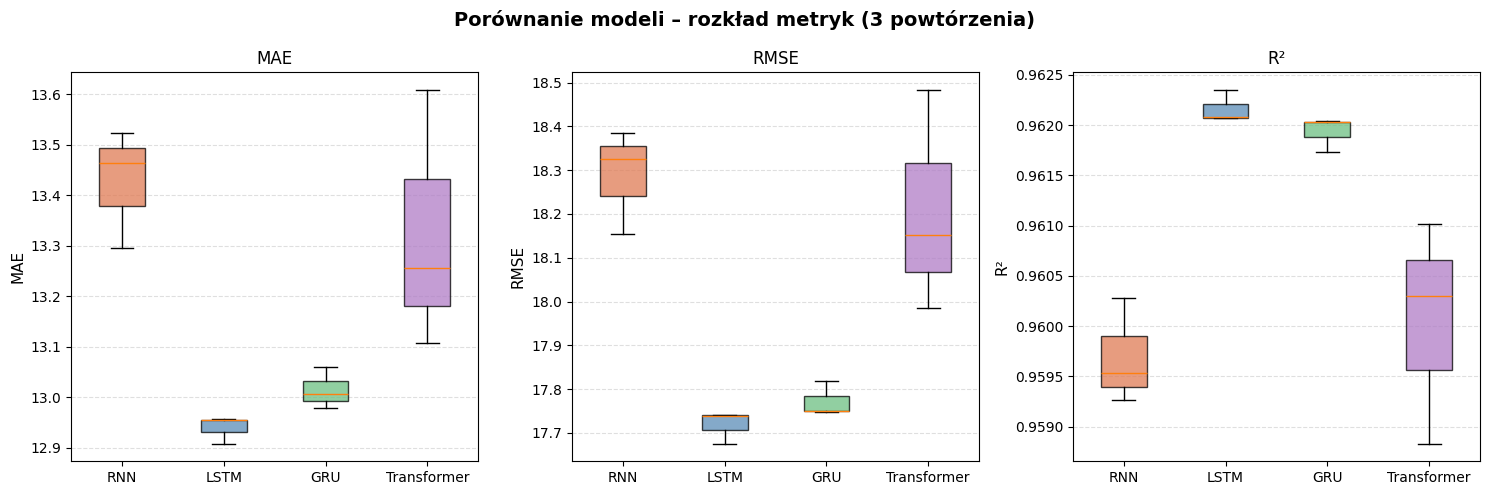

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Porównanie modeli – rozkład metryk (3 powtórzenia)", fontsize=14, fontweight="bold")

for ax, metric, label in zip(axes, ["mae", "rmse", "r2"], ["MAE", "RMSE", "R²"]):
    data_plot = [df_res[df_res["model"] == m][metric].values for m in MODEL_CONFIGS]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False)
    for patch, m in zip(bp["boxes"], MODEL_CONFIGS):
        patch.set_facecolor(PALETTE[m])
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(MODEL_CONFIGS) + 1))
    ax.set_xticklabels(list(MODEL_CONFIGS.keys()), fontsize=10)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "boxplot_metrics.png"), dpi=150)
plt.show()

## Porównaie metryk poszczególnych modeli ciąg dalszy 

Wykres może nudniejszy od tego powyżej jednak "sprowadza nas na ziemiemie" z porównaniami - widzimy że tak naprawde modele osiągały bardzo podobne wyniki.

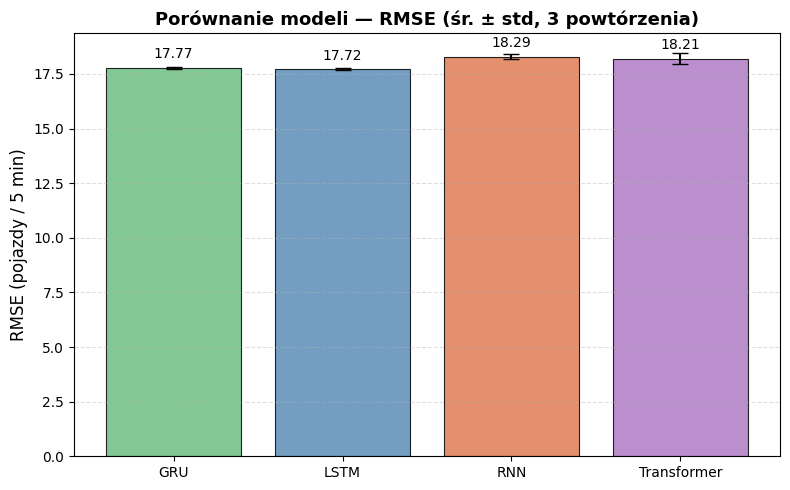

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
models  = summary["model"].tolist()
means   = summary["RMSE_mean"].tolist()
stds    = summary["RMSE_std"].fillna(0).tolist()
colors  = [PALETTE[m] for m in models]
bars    = ax.bar(models, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor="k", lw=0.8)
ax.set_ylabel("RMSE (pojazdy / 5 min)", fontsize=12)
ax.set_title("Porównanie modeli — RMSE (śr. ± std, 3 powtórzenia)", fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "rmse_comparison.png"), dpi=150)
plt.show()

## Porównanie krzywych treningowych

Wyniki są barzdo zbliżone dla poszczególnych modeli. Nie widać szczególnych błędów - uzcenie zachodziło poprawnie.

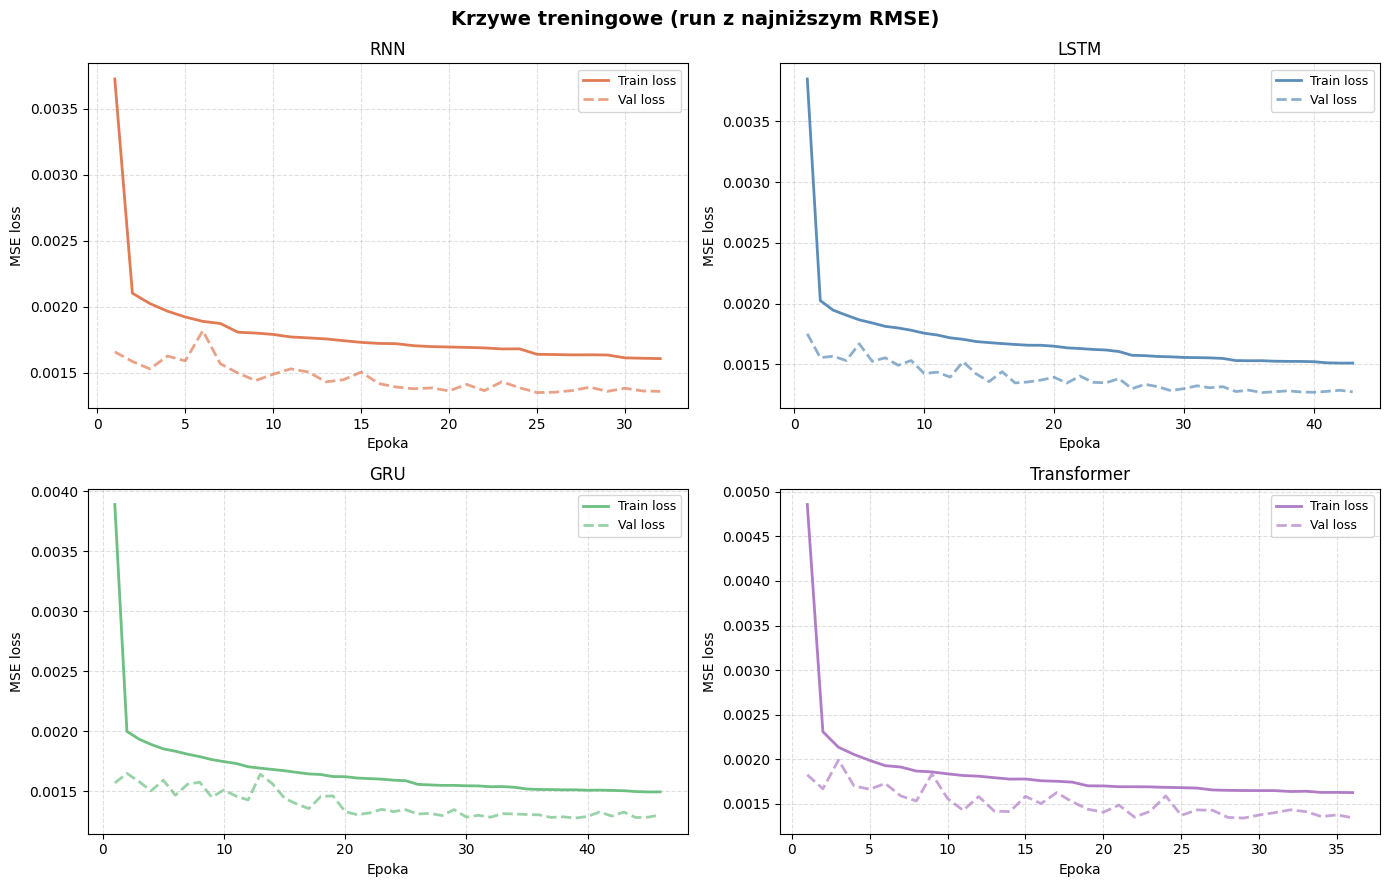

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Krzywe treningowe (run z najniższym RMSE)", fontsize=14, fontweight="bold")

for ax, model_name in zip(axes.flatten(), MODEL_CONFIGS):
    best_run = df_res[df_res["model"] == model_name].sort_values("rmse").iloc[0]
    run_data = next(r for r in all_results
                    if r["model"] == model_name and r["run"] == int(best_run["run"]))
    h = run_data["history"]
    epochs = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs, h["train_loss"], label="Train loss", color=PALETTE[model_name], lw=2)
    ax.plot(epochs, h["val_loss"],   label="Val loss",   color=PALETTE[model_name], lw=2, ls="--", alpha=0.7)
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Epoka")
    ax.set_ylabel("MSE loss")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

## Porównanie prdykcja vs rzeczywistość 

Tu widzimy że mimo wyraźnych różnic na wykresie porównujących metryki tak anprawde każdy z modeli poradził sobie naprawdę dobrze. 

Nie widzę jednak tutaj wystarczających przesłanek do zmiany określenie który model jest najlepszy ponieważ GRU, które po względem metryk było zaraz za LSTM liczyło się blistko 2 razy dłużej niż LSTM.

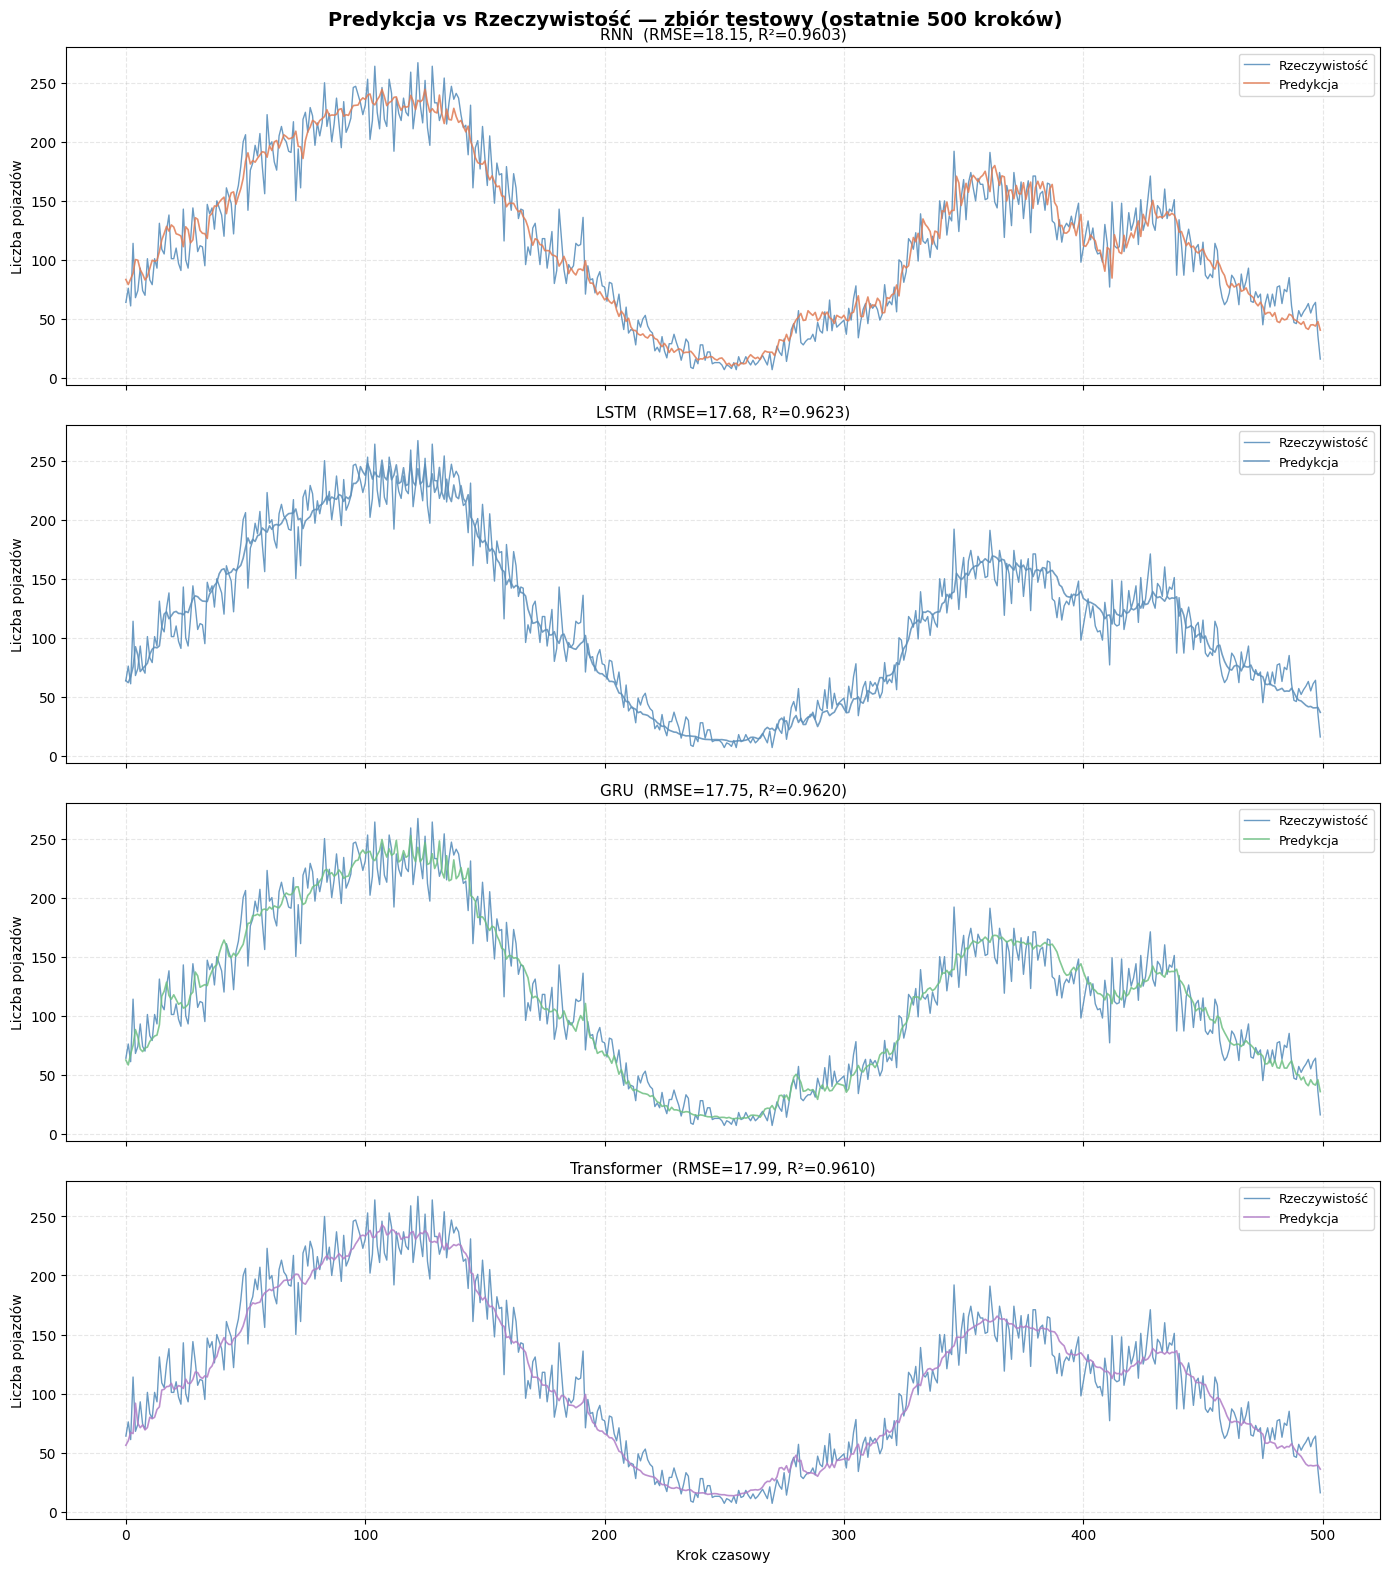

In [ ]:
fig, axes = plt.subplots(len(MODEL_CONFIGS), 1, figsize=(14, 4 * len(MODEL_CONFIGS)), sharex=True)
fig.suptitle("Predykcja vs Rzeczywistość — zbiór testowy (ostatnie 500 kroków)", fontsize=14, fontweight="bold")

for ax, model_name in zip(axes, MODEL_CONFIGS):
    best_run = df_res[df_res["model"] == model_name].sort_values("rmse").iloc[0]
    run_data = next(r for r in all_results
                    if r["model"] == model_name and r["run"] == int(best_run["run"]))
    a = run_data["actuals"][-500:]
    p = run_data["preds"][-500:]
    ax.plot(a, label="Rzeczywistość", color="steelblue",  lw=1.0, alpha=0.8)
    ax.plot(p, label="Predykcja",    color=PALETTE[model_name], lw=1.2, alpha=0.85)
    r2_val = r2_score(run_data["actuals"], run_data["preds"])
    ax.set_title(f"{model_name}  (RMSE={best_run['rmse']:.2f}, R²={r2_val:.4f})", fontsize=11)
    ax.set_ylabel("Liczba pojazdów")
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(linestyle="--", alpha=0.3)

axes[-1].set_xlabel("Krok czasowy")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "predictions_vs_actual.png"), dpi=150)
plt.show()

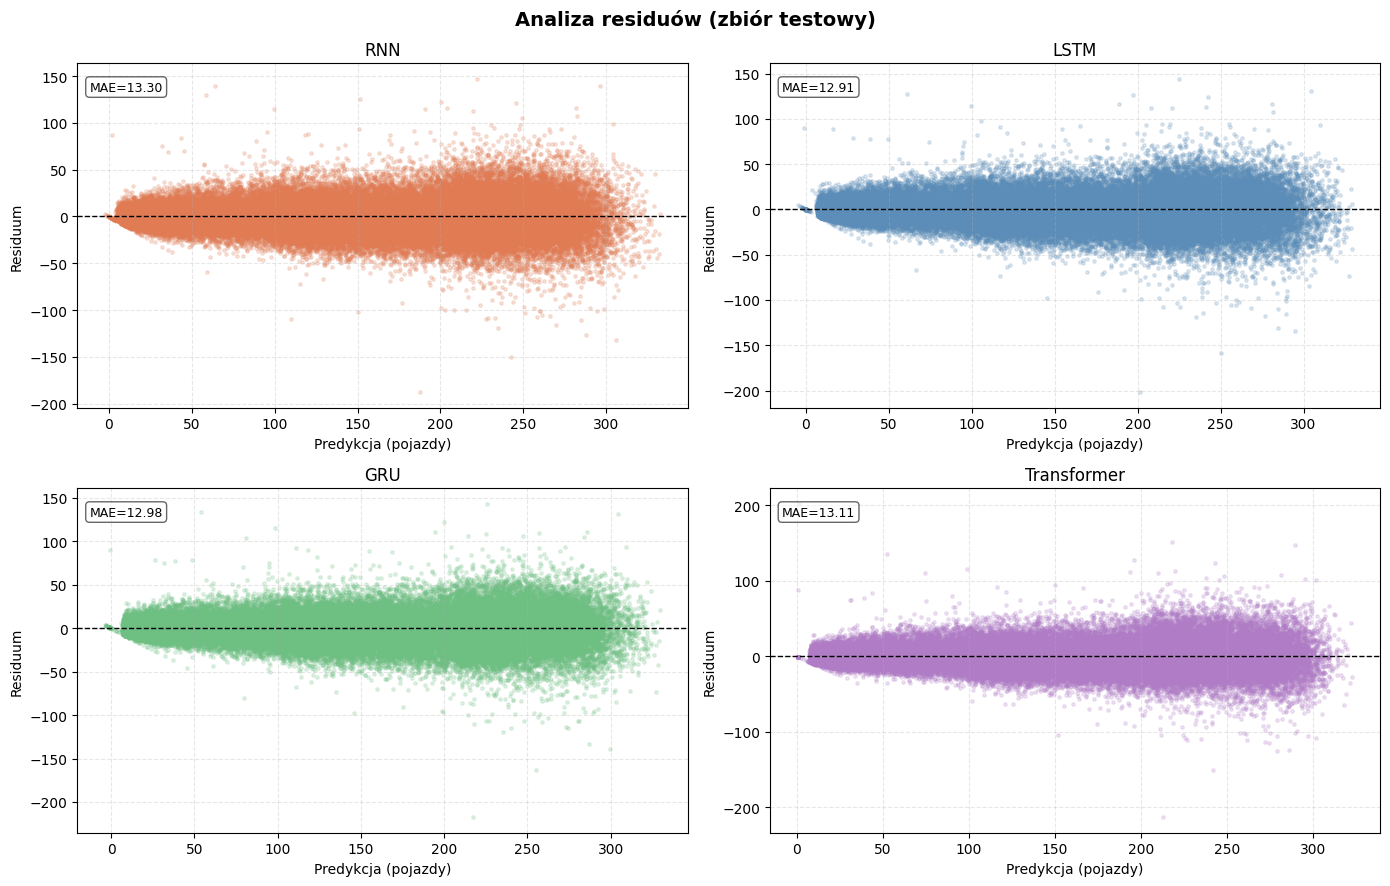

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Analiza residuów (zbiór testowy)", fontsize=14, fontweight="bold")

for ax, model_name in zip(axes.flatten(), MODEL_CONFIGS):
    best_run = df_res[df_res["model"] == model_name].sort_values("rmse").iloc[0]
    run_data = next(r for r in all_results
                    if r["model"] == model_name and r["run"] == int(best_run["run"]))
    residuals = run_data["actuals"] - run_data["preds"]
    ax.scatter(run_data["preds"], residuals, alpha=0.2, s=6, color=PALETTE[model_name])
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.set_xlabel("Predykcja (pojazdy)")
    ax.set_ylabel("Residuum")
    ax.set_title(model_name, fontsize=12)
    ax.grid(linestyle="--", alpha=0.3)
    ax.text(0.02, 0.95, f"MAE={best_run['mae']:.2f}", transform=ax.transAxes,
            fontsize=9, verticalalignment="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.6))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "residual_plot.png"), dpi=150)
plt.show()

## Wyniki cross-validacji wykonanej dla LSTM

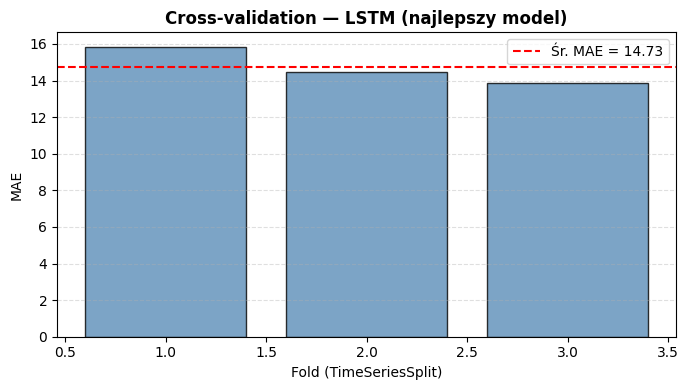

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
folds = range(1, len(cv_scores) + 1)
ax.bar(folds, cv_scores, color=PALETTE.get(best_model_name, "steelblue"), alpha=0.8, edgecolor="k")
ax.axhline(np.mean(cv_scores), color="red", ls="--", lw=1.5, label=f"Śr. MAE = {np.mean(cv_scores):.2f}")
ax.set_xlabel("Fold (TimeSeriesSplit)")
ax.set_ylabel("MAE")
ax.set_title(f"Cross-validation — {best_model_name} (najlepszy model)", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "cross_validation.png"), dpi=150)
plt.show()

## Optymalizacja hiperparametrów na LSTM - poprzednio najlepszym modelu.

Wykonano porównanie 4 zestawów hiperparametrów:  
- {"hidden": 32,  "layers": 1, "dropout": 0.1, "lr": 1e-3}
- {"hidden": 64,  "layers": 2, "dropout": 0.2, "lr": 1e-3}
- {"hidden": 128, "layers": 2, "dropout": 0.3, "lr": 5e-4}
- {"hidden": 64,  "layers": 3, "dropout": 0.2, "lr": 1e-3}  

Osiągnięto najlepszy wynik RMSE dla zaestawu drugirgo {"hidden": 64,  "layers": 2, "dropout": 0.2, "lr": 1e-3}, jednak wyniki pomiędzy poszczególnymi kombinacjami są nieznaczne. Dużą różnicą była rednak złożoność obiczeniowa i czas obliczeń zestaw 1 uczył się około 8 minut, a drugi 30 min. 

Wniosek: jako najlepszy model można wybrać wersje {"hidden": 32,  "layers": 1, "dropout": 0.1, "lr": 1e-3}.

02:42:11 | 
=== Optymalizacja hiperparametrów (LSTM, grid search) ===
02:50:43 |   h=32, L=1, do=0.1, lr=0.001  →  RMSE=17.81  MAE=13.06
03:21:06 |   h=64, L=2, do=0.2, lr=0.001  →  RMSE=17.74  MAE=12.95
04:41:37 |   h=128, L=2, do=0.3, lr=0.0005  →  RMSE=17.78  MAE=13.03
05:23:52 |   h=64, L=3, do=0.2, lr=0.001  →  RMSE=17.82  MAE=13.00


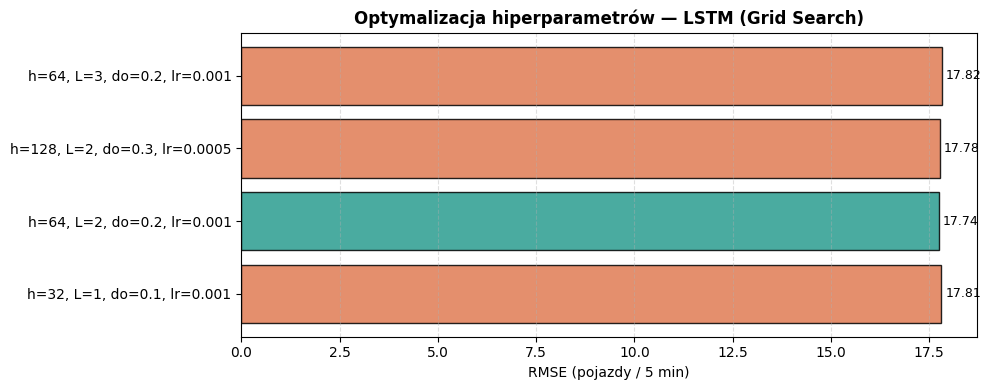

In [ ]:
log.info("\n=== Optymalizacja hiperparametrów (LSTM, grid search) ===")

HYPERPARAM_GRID = [
    {"hidden": 32,  "layers": 1, "dropout": 0.1, "lr": 1e-3},
    {"hidden": 64,  "layers": 2, "dropout": 0.2, "lr": 1e-3},
    {"hidden": 128, "layers": 2, "dropout": 0.3, "lr": 5e-4},
    {"hidden": 64,  "layers": 3, "dropout": 0.2, "lr": 1e-3},
]

hp_results = []

for cfg_hp in HYPERPARAM_GRID:
    hidden  = cfg_hp["hidden"]
    layers  = cfg_hp["layers"]
    dropout = cfg_hp["dropout"]
    lr_hp   = cfg_hp["lr"]

    model = LSTMModel(N_FEATURES, hidden=hidden, layers=layers,
                      dropout=dropout, pred_len=PRED_LEN).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr_hp)
    crit  = nn.MSELoss()
    best_vl, bw, no_imp = float("inf"), None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        vl_loss = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                            for xb, yb in val_loader])
        if vl_loss < best_vl:
            best_vl, bw, no_imp = vl_loss, deepcopy(model.state_dict()), 0
        else:
            no_imp += 1
        if no_imp >= PATIENCE:
            break

    model.load_state_dict(bw); model.eval()
    preds, acts = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
            acts.append(yb.numpy())
    p = scaler_y.inverse_transform(np.concatenate(preds)).flatten()
    a = scaler_y.inverse_transform(np.concatenate(acts)).flatten()
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = mean_absolute_error(a, p)
    label = f"h={hidden}, L={layers}, do={dropout}, lr={lr_hp}"
    hp_results.append({"label": label, "rmse": rmse, "mae": mae})
    log.info(f"  {label}  →  RMSE={rmse:.2f}  MAE={mae:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
labels = [r["label"] for r in hp_results]
rmses  = [r["rmse"]  for r in hp_results]
best_hp_idx = int(np.argmin(rmses))
colors_hp = ["#e07b54" if i != best_hp_idx else "#2a9d8f" for i in range(len(hp_results))]
ax.barh(labels, rmses, color=colors_hp, edgecolor="k", alpha=0.85)
ax.set_xlabel("RMSE (pojazdy / 5 min)")
ax.set_title("Optymalizacja hiperparametrów — LSTM (Grid Search)", fontsize=12, fontweight="bold")
ax.grid(axis="x", linestyle="--", alpha=0.4)
for i, v in enumerate(rmses):
    ax.text(v + 0.1, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "hyperparam_search.png"), dpi=150)
plt.show()

In [93]:
print("KOŃCOWE PODSUMOWANIE")
print()
print(summary[["model","MAE_mean","MAE_std","RMSE_mean","RMSE_std",
               "R2_mean","MAPE_mean","Epochs_mean","Time_s"]].to_string(index=False))
print(f"\nNajlepszy model (śr. RMSE): {best_model_name}")
print(f"Cross-validation ({best_model_name}): MAE = {np.mean(cv_scores):.2f} ± {np.std(cv_scores):.2f}")

KOŃCOWE PODSUMOWANIE

      model  MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean   MAPE_mean  Epochs_mean      Time_s
        GRU 13.014834 0.041319  17.772461  0.040163 0.961935 194567168.0    44.666667 2504.785779
       LSTM 12.939201 0.027093  17.719057  0.037504 0.962164 144577856.0    47.666667 1539.794980
        RNN 13.426964 0.117825  18.288447  0.120081 0.959692 180100672.0    27.000000  636.859899
Transformer 13.323459 0.257638  18.206497  0.253285 0.960048 115807208.0    35.000000 3489.630213

Najlepszy model (śr. RMSE): LSTM
Cross-validation (LSTM): MAE = 14.73 ± 0.82
